<a href="https://colab.research.google.com/github/me1-3/Emsc2010-A3/blob/main/EMSC2010_A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Title:

Dataset used:

- Original -->
  - Name:
  - Source: https://www.bco-dmo.org/dataset/936073
- Cleaned -->
  - Name:
  - Source:

  AIM: To use Bayesian inference to determine the posterior probability that the mean pH after 2020 is higher than before 2020.

In [36]:
# Import required packages for data handling, plotting, modelling, and model comparison

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pymc as pm
import arviz as az


Found existing installation: bambi 0.18.0
Uninstalling bambi-0.18.0:
  Successfully uninstalled bambi-0.18.0


In [25]:
spreadsheet_name = 'ph.xlsx'
worksheet_name = 'sheet1'

df = pd.read_excel(spreadsheet_name, sheet_name=worksheet_name)

In [27]:
# Clean column names by removing extra spaces, making names uppercase, and replacing spaces with underscores

df.columns = df.columns.str.strip().str.upper().str.replace(' ', '_')

# Display the first few rows to check that the dataset loaded correctly

df.head()

,LOCATION,LAT,LON,SERIAL_NUMBER,ISO_DATETIME_EST,TEMP,PH,PH_FLAG,COND,HDO_MGL,HDO_PERCENTSAT,SALINITY,SALINITY_FLAG,DEPTH,COMMENTS,ISO_DATETIME_UTC
0,Mumford Cove,41.325261,-72.02088,3151819,2015-04-14T14:30,10.30,8.31,NaN,43860.0,11.23,118.4,28.16,NaN,NaN,NaN,2015-04-14T18:30Z
1,Mumford Cove,41.325261,-72.02088,3151819,2015-04-14T15:00,10.95,8.36,NaN,43880.0,12.17,130.1,28.21,NaN,NaN,NaN,2015-04-14T19:00Z
2,Mumford Cove,41.325261,-72.02088,3151819,2015-04-14T15:30,10.36,8.34,NaN,43890.0,12.12,127.9,28.18,NaN,NaN,NaN,2015-04-14T19:30Z
3,Mumford Cove,41.325261,-72.02088,3151819,2015-04-14T16:00,8.85,8.30,NaN,44500.0,11.78,120.4,28.53,NaN,NaN,NaN,2015-04-14T20:00Z
4,Mumford Cove,41.325261,-72.02088,3151819,2015-04-14T16:30,8.45,8.30,NaN,44800.0,11.98,121.6,28.71,NaN,NaN,NaN,2015-04-14T20:30Z


In [35]:
df['ISO_DATETIME_UTC_YEAR'] = pd.to_datetime(df['ISO_DATETIME_UTC']).dt.year

#SELECT EARLY YEAR GROUPS FROM THE DATASET

data_early = df[(df["ISO_DATETIME_UTC_YEAR"] < 2020)]["PH"].dropna()
data_early = data_early[data_early>0]
data_early = np.log10(data_early)

#SELECT RECENT YEAR GROUPS FROM THE DATASET
data_recent = df[(df["ISO_DATETIME_UTC_YEAR"] >= 2020)]["PH"].dropna()
data_recent = data_recent[data_recent>0]
data_recent = np.log10(data_recent)

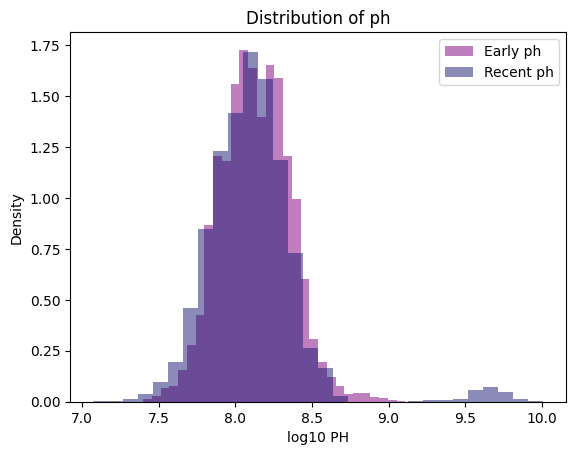

In [30]:

#PLOT HISTOGRAMS TO VISUALISE DISTRIBUTION OF CATCH FOR EACH GROUP
plt.hist(data_early, bins=30, alpha=0.5, color='purple', label='Early (<2020)', density=True)
plt.hist(data_recent, bins=30, alpha=0.5, color='midnightblue', label='Recent (>=2020)', density=True)

#LABELS
plt.xlabel("log10 PH")
plt.ylabel("Density")
plt.title("Distribution of ph")
plt.legend(["Early ph", "Recent ph"])

#SHOW
plt.show() #show plot

In [33]:
#BAYESIAN MODEL ESTIMATING MEAN CATCH FOR EARLY YEARS

with pm.Model() as early_model:

  # Prior for the mean — Normal centered at your best prior guess with sigma representing the uncertainty in that guess
  mu = pm.Normal("mu", mu = 3, sigma = 2)

  # Prior for std of heights — HalfNormal with a standard deviation of 20.
  sigma = pm.HalfNormal ("sigma", sigma = 2)

  # Likelihood given the data
  obs = pm.Normal ("obs", mu = mu, sigma = sigma, observed = data_early)

   # Obtain 20,000 samples from the posterior
  trace_early = pm.sample(20000, tune = 2000, return_inferencedata = True, progressbar = False)

  # Plot the posterior distribution for the mean
az.plot_posterior(trace_early, var_names=["mu"])


AttributeError: module 'arviz' has no attribute 'plot_posterior'

In [ ]:
with pm.Model() as recent_model:

  # Prior for the mean — Normal centered at your best prior guess with sigma representing the uncertainty in that guess
  mu = pm.Normal("mu", mu = 3, sigma = 2)

  # Prior for std of heights — HalfNormal with a standard deviation of 20.
  sigma = pm.HalfNormal ("sigma", sigma = 2)

  # Likelihood given the data
  obs = pm.Normal ("obs", mu = mu, sigma = sigma, observed = data_recent)

   # Obtain 20,000 samples from the posterior
  trace_recent = pm.sample(20000, tune = 2000, return_inferencedata = True, progressbar = False)

  # Plot the posterior distribution for the mean
az.plot_posterior(trace_recent, var_names=["mu"])

In [ ]:
#PLOT DISTRIBUTION OF DIFFERENCE IN MEAN CATCH BETWEEN GROUPS
mu_diff = mu_samples_recent - mu_samples_early

#HISTOGRAM
plt.hist(mu_diff, bins = 51, color="teal")

#LABELS
plt.xlabel("Difference in mean log10 catch (recent - early) [kg]")
plt.ylabel("Frequency")
plt.title("Posterior Distribution of Mean Difference")

#SHOW
plt.show() #show plot

In [ ]:

#CALCULATE THE 95% HIGHEST DENSITY INTERVAL (CREDIBLE INTERVAL)

az.hdi(mu_diff, hdi_prob = 0.95)

In [ ]:

#CALCULATE PROBABILITY THAT RECENT MEAN CATCH IS GREATER THAN EARLY MEAN CATCH

np.mean(mu_diff > 0)

In [ ]:
print("Probability that recent mean catch is higher than early mean catch =", np.mean(mu_diff > 0))